                               MAchiNe LEArning
ROLLNO : BSEf23M036
Assignment 02
Submitted to : Mam Madiha

In [27]:
!pip install kagglehub


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import kagglehub 
path = kagglehub.dataset_download("yasserh/housing-prices-dataset") 
print("Path to dataset files:", path) 

Path to dataset files: C:\Users\BUTT\.cache\kagglehub\datasets\yasserh\housing-prices-dataset\versions\1


Data Loading ANd PRePRocessing and viewsing

In [29]:
import pandas as pd
data=pd.read_csv(path+"/housing.csv")
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [30]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [31]:
data.shape

(545, 13)

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


will check for which columns have null values and how many

In [33]:
print(data.isna().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


Check how many rows will drop

In [34]:
import numpy as np
originalDataOFRows=data.shape[0]
threshold=0.3*data.shape[1]

data.dropna(thresh=int(data.shape[1]-threshold),inplace=True)
removedRows=data.shape[0]

dropremivedRows=originalDataOFRows-removedRows

print(f"% of Rows drop: {(dropremivedRows/originalDataOFRows)*100:.2f}%")

numberCol=data.select_dtypes(include=[np.number]).columns
print(data.isna().sum())

% of Rows drop: 0.00%
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


Convertions categorical to numerical data changing

In [35]:
categoryCol=['mainroad','basement','guestroom','hotwaterheating','airconditioning','prefarea']
for i in categoryCol:
    data[i]=data[i].map({'yes':1,'no':0})

furnishMApping={'unfurnished':0,'semi-furnished':1,'furnished':2}
data['furnishingstatus']=data['furnishingstatus'].map(furnishMApping)
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


Manual data Spliting for 80:20 ratio

In [36]:
X=data.drop('price',axis=1)
y=data['price'].values

MEANValue=X.mean()
STandadardDev=X.std()


Xscales=(X-MEANValue)/STandadardDev
XScales=Xscales.values


RandomLengthData=np.random.permutation(len(Xscales))
Xshuffled = XScales[RandomLengthData]
yshuffled = y[RandomLengthData]

splitingCriteria=int(.8 * len(Xscales))

trainingX = Xshuffled[:splitingCriteria]
testingX = Xshuffled[splitingCriteria:]

trainingY = yshuffled[:splitingCriteria]
testingY = yshuffled[splitingCriteria:]

print("Traing data size: ",trainingX.shape)
print("Testing Data size:",testingX.shape)


Traing data size:  (436, 12)
Testing Data size: (109, 12)


Matrix designing of one's column first insert

In [37]:
def MatrixOfOneColFirst(X):
    matrixInsertion=np.ones((X.shape[0],1))
    return np.hstack((matrixInsertion,X))


Prediction Dunction As: theta*X

In [38]:
trainingX = MatrixOfOneColFirst(trainingX)
testingX = MatrixOfOneColFirst(testingX)

def predictionFunction(X,ValuesOfThetaForData):
    return np.dot(X,ValuesOfThetaForData)

Gradient Descent Implement

In [39]:
def MeanSqaureError(X,y,ValueofTheta):
    m=len(y)
    YHat=predictionFunction(X,ValueofTheta)
    errorsValue=(1/(2*m)) * np.sum((YHat - y)**2)
    return errorsValue

def GradientDescent(X,y,ValueofTheta,learningRate,numOFIterations):
    m=len(y)
    CostValues=[]

    for i in range(numOFIterations):
        predictionsValues=predictionFunction(X,ValueofTheta)
        errors=predictionsValues-y

        gradient=(1/m) * np.dot(X.T,errors)
        ValueofTheta=ValueofTheta-learningRate*gradient

        CostCalculatedvalue=MeanSqaureError(X,y,ValueofTheta)
        CostValues.append(CostCalculatedvalue)

    return ValueofTheta,CostValues    

In [40]:
theta=np.zeros(trainingX.shape[1])

alphaValue=0.01
epoxes=1000
theta,CostValues=GradientDescent(trainingX,trainingY,theta,alphaValue,epoxes)
print("Theta values after training: ",theta)
print("Final Cost: ",CostValues[-1])

Theta values after training:  [4728899.82193955  509427.03235604   93048.85212211  454904.44537108
  403052.75791807  153487.3100842   118363.83351623  177324.28622915
  210140.03467658  432242.53900425  211578.78821106  273903.12612545
  178728.71847183]
Final Cost:  564774561562.5122


In [41]:
pred=predictionFunction(testingX,theta)
mse=np.mean((pred-testingY)**2)

print("Mean Squared Error: ",mse)

Mean Squared Error:  1097333008944.5165


Comparing Inital And Final Resulted Cost

In [42]:
print("Initial Cost:", CostValues[0])
print("Final Cost:", CostValues[-1])

Initial Cost: 12652405086728.787
Final Cost: 564774561562.5122


In [43]:
MedianPrice=data['price'].median()
data['target']=data['price'].apply(lambda x: 1 if x>=MedianPrice else 0)
Yclassification=data['target'].values

Xclassification=data.drop(['price','target'],axis=1).values
MEanOFX=Xclassification.mean(axis=0)
standDeviationOfX=Xclassification.std(axis=0)
Xclassification=(Xclassification-MEanOFX)/standDeviationOfX

LengthOfClassification=np.random.permutation(len(Xclassification))
Xclassification=Xclassification[LengthOfClassification]
Yclassification=Yclassification[LengthOfClassification]
dataSplitingweightage=int(0.8*len(Xclassification))

In [44]:
traingValueOfXClassif=Xclassification[:dataSplitingweightage]
testValueOfXclassif=Xclassification[dataSplitingweightage:]

trainingValueOfYClassif=Yclassification[:dataSplitingweightage]
testingValueOfYClassif=Yclassification[dataSplitingweightage:]

traingValueOfXClassif=MatrixOfOneColFirst(traingValueOfXClassif)
testValueOfXclassif=MatrixOfOneColFirst(testValueOfXclassif)
def Sigmoid(Z):
    return 1/(1+np.exp(-Z))

print(Sigmoid(0),Sigmoid(100),Sigmoid(-100).round(1))

0.5 1.0 0.0


In [45]:
def costFunction(X,y,theta):
    m=len(y)
    hVlaue=Sigmoid(np.dot(X,theta))
    epsilon = 1e-8
    costResult=-(1/m)* np.sum(y*np.log(hVlaue+epsilon)+(1-y)*np.log(1-hVlaue+epsilon))
    return costResult

In [46]:
def gradDescentLogisticRegression(X,y,theta,learningRate,numOfIterations):
    CostingValuesList=[]
    m=len(y)

    for i in range(numOfIterations):
        z=np.dot(X,theta)
        h=Sigmoid(z)
        gradient=(1/m)*np.dot(X.T,(h-y))
        theta=theta-learningRate*gradient

        cost=costFunction(X,y,theta)
        CostingValuesList.append(cost) 
        
    return theta,CostingValuesList
CheckingTheta1=np.zeros(traingValueOfXClassif.shape[1])
checkingTheta2=np.zeros(traingValueOfXClassif.shape[1])

checkingTheta1,CostValues1=gradDescentLogisticRegression(traingValueOfXClassif,trainingValueOfYClassif,CheckingTheta1,0.01,1000)
checkingTheta2,CostValues2=gradDescentLogisticRegression(traingValueOfXClassif,trainingValueOfYClassif,checkingTheta2,0.1,1000)

PredctionCLassification Function

In [47]:
def predictionFunctionForClassification(X,theta):
    probabilityVal=Sigmoid(np.dot(X,theta))
    return np.array([1 if probabilityVal[i]>=.5 else 0 for i in range(len(probabilityVal))])

YPred=predictionFunctionForClassification(testValueOfXclassif,checkingTheta1)
accuracyValue=np.mean(YPred==testingValueOfYClassif)
print("Classification Accuracy Result: ",accuracyValue)


Classification Accuracy Result:  0.7981651376146789


In [48]:
TP=np.sum((YPred==1)& (testingValueOfYClassif==1))
TN=np.sum((YPred==0)& (testingValueOfYClassif==0))
FP=np.sum((YPred==1)& (testingValueOfYClassif==0))
FN=np.sum((YPred==0)& (testingValueOfYClassif==1))
confusionMatrix=np.array([[TP,FP],[FN,TN]])
print("Confusion Matrix:\n",confusionMatrix)

Confusion Matrix:
 [[43  9]
 [13 44]]


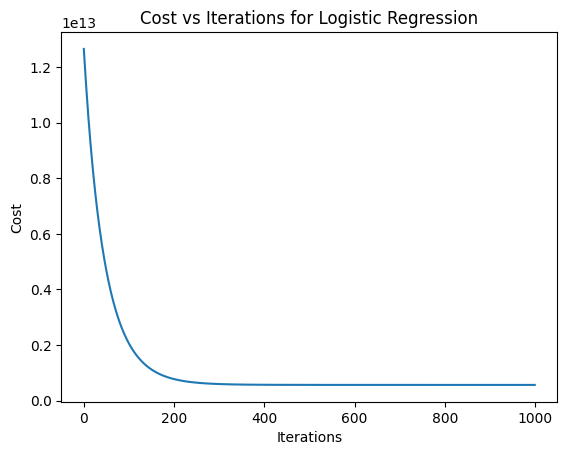

In [49]:
import matplotlib.pyplot as plt
plt.plot(CostValues)
plt.title("Cost vs Iterations for Logistic Regression")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

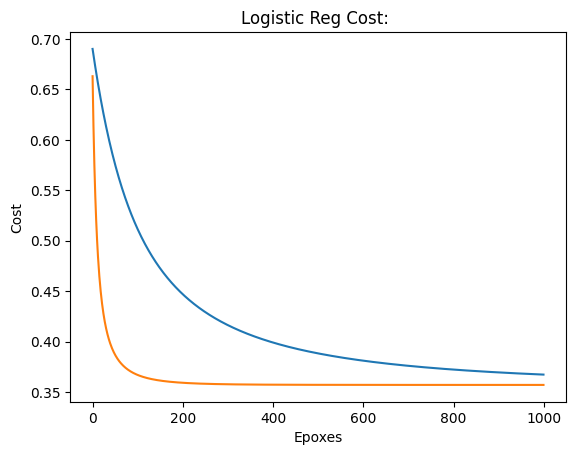

In [50]:
plt.plot(CostValues1,label='Learning Rate 0.01')
plt.plot(CostValues2,label='Learning Rate 0.1')
plt.title("Logistic Reg Cost: ")
plt.xlabel("Epoxes")
plt.ylabel("Cost")
plt.show()


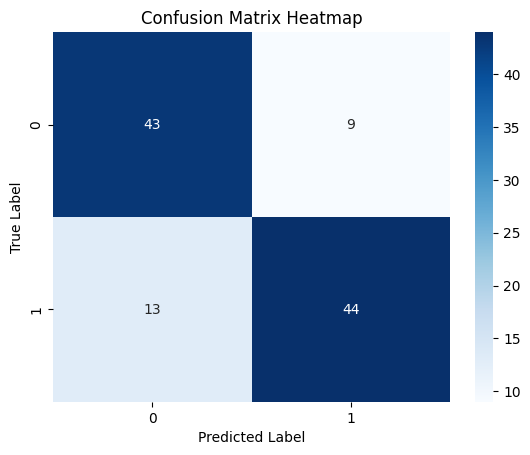

In [51]:
import seaborn as sns
sns.heatmap(confusionMatrix,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
#OBSerVationn Of COnfusion MatRix:
#The heatmap demonstrates that the model performs well overall 
# properly classifying the majority of data with high true positives and true negatives
# Even some reasonably priced homes are mistakenly categorized as pricely
# it does somewhat better at predicting expensive homes